# Sistema inteligente de planificación de rutas en TransMilenio (datos reales)

**Actividad:** Sistema inteligente basado en una base de conocimiento escrita en
reglas lógicas que, dado un punto de origen **A** y un punto de destino **B**
dentro del sistema de transporte masivo TransMilenio (Bogotá, Colombia),
calcula la mejor ruta posible.

El desarrollo se apoya en tres bloques de conocimiento de inteligencia artificial:

1. **Lógica y representación del conocimiento** — cómo modelar la red real de
   transporte (estaciones, líneas, conexiones) como un conjunto de hechos y
   predicados lógicos.
2. **Sistemas basados en reglas** — un motor de inferencia por
   *encadenamiento hacia adelante* (*forward chaining*) que, a partir de los
   hechos, deriva todas las transiciones posibles (moverse por una línea,
   transbordar de línea) del "mundo" TransMilenio.
3. **Técnicas de búsqueda heurística** — el algoritmo **A\*** para explorar
   el espacio de estados generado por el motor de reglas y encontrar la ruta
   de menor costo (tiempo estimado) entre A y B.

> ### Fuente de los datos: información oficial y real de TransMilenio
>
> Las **152 estaciones troncales** y las **13 troncales/corredores** que se
> usan en este notebook se obtuvieron directamente del servicio geográfico
> oficial de TransMilenio S.A. (ArcGIS FeatureServer), capas *"Estación
> troncal"* y *"Trazado troncal"*, filtrando únicamente estaciones con
> estado `EXISTENTE` (actualmente operativas):
>
> `https://gis.transmilenio.gov.co/arcgis/rest/services/ConsultaSubgerenciaPlanificacionSITP/Consulta_Planificacion_SITP/FeatureServer`
>
> Este mismo servicio alimenta el portal de datos abiertos de Bogotá
> ([Estaciones Troncales de TRANSMILENIO](https://datosabiertos.bogota.gov.co/dataset/estaciones-troncales-de-transmilenio),
> licencia CC-BY-4.0). Las coordenadas originales vienen en el sistema de
> referencia **EPSG:3116** (MAGNA-SIRGAS / Bogotá) y se reproyectan aquí a
> **EPSG:4326** (lat/lon) con `pyproj`.
>
> **Lo que SÍ es real:** nombres de estaciones, a qué troncal pertenece cada
> una, y su ubicación geográfica exacta.
> **Lo que es una aproximación razonable:** el *orden* de las estaciones a lo
> largo de cada troncal (el dataset no trae el orden de paradas como lo
> haría un feed GTFS, así que se reconstruye con un heurístico de vecino más
> cercano sobre las coordenadas reales — ver sección 1.3), los tiempos de
> viaje (estimados por distancia real y velocidad comercial promedio) y los
> transbordos entre estaciones de nombre distinto pero del mismo complejo
> físico (se infieren por cercanía geográfica real, ver Regla R4).


## 0. Preparación del entorno

Se usan librerías estándar de Python (`math`, `heapq`, `collections`,
`difflib`, `itertools`) para la lógica del sistema, `pyproj` para convertir
las coordenadas oficiales a lat/lon, `networkx` + `matplotlib` para una
vista esquemática de la red, `folium` para mostrar la red y la ruta sobre un
**mapa real de Bogotá**, e `ipywidgets` para las cajas de texto interactivas
donde escribirás tu origen y tu destino.

La siguiente celda **instala automáticamente** en el kernel que estás usando
(con `sys.executable -m pip`, para evitar el típico problema de VS Code /
Jupyter donde `pip install` en una terminal instala en un Python distinto al
del kernel del notebook) cualquiera de estas librerías que todavía no
tengas, y luego las importa. Si tu entorno no tiene acceso a internet para
instalar paquetes, instálalas manualmente en el mismo entorno donde corre
el kernel (`pip install networkx matplotlib folium ipywidgets pyproj`) y
vuelve a ejecutar la celda.


In [1]:
import sys
import subprocess
import importlib

PAQUETES = {
    "networkx": "networkx",
    "matplotlib": "matplotlib",
    "folium": "folium",
    "ipywidgets": "ipywidgets",
    "pyproj": "pyproj",
}

for modulo, paquete_pip in PAQUETES.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        print(f"Instalando '{paquete_pip}' en el kernel actual ({sys.executable}) ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete_pip])

import math
import heapq
import difflib
import itertools
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output
from pyproj import Transformer

%matplotlib inline

print("Entorno listo.")


Entorno listo.


## 1. Lógica y representación del conocimiento

Representamos la red de TransMilenio como una **base de hechos** declarativa,
inspirada en predicados lógicos de primer orden:

```
estacion(Nombre, Latitud, Longitud).
pertenece(Estacion, Linea).
conecta(EstacionA, EstacionB, Linea, Tiempo).
```

* `estacion/3` — cada estación existe en un punto geográfico concreto (real).
* `pertenece/2` — una estación puede pertenecer a **una o varias** líneas
  troncales reales; cuando pertenece a más de una, es una estación de
  **transbordo**.
* `conecta/4` — dos estaciones consecutivas de una misma línea están unidas
  por un arco con un tiempo de viaje asociado.

### 1.1. Hechos crudos tal como se obtuvieron del servicio oficial

Cada fila es `(nombre_estacion, id_trazado, x, y)`, con `x, y` en EPSG:3116.
`id_trazado` identifica el tramo/trazado físico sobre el que está construida
la estación; `TRAZADO_A_TRONCAL` traduce ese identificador al **nombre real**
de la troncal (obtenido de la capa "Trazado troncal").


In [2]:
# id_trazado -> nombre real de la troncal
# (capa "Trazado troncal" del servicio oficial, campo nom_tronc)
TRAZADO_A_TRONCAL = {
    "TZ001": "Caracas",
    "TZ002": "Autopista Norte",
    "TZ003": "Suba",
    "TZ004": "Suba",
    "TZ005": "Calle 80",
    "TZ006": "Calle 80",
    "TZ007": "NQS Central",
    "TZ008": "NQS Central",
    "TZ009": "Americas",
    "TZ010": "NQS Sur",
    "TZ011": "NQS Sur",
    "TZ012": "Caracas Sur",
    "TZ013": "Caracas Sur",
    "TZ014": "Caracas Sur",
    "TZ015": "Eje Ambiental",
    "TZ016": "Calle 26",
    "TZ017": "Calle 26",
    "TZ018": "Carrera 10",
    "TZ019": "Carrera 7",
    "TZ020": "Carrera 7",
    "TZ022": "Avenida Ciudad de Cali",
    "TZ022A": "Avenida Ciudad de Cali",
}

# (nombre_estacion, id_trazado, x, y)  -- x, y en EPSG:3116 (metros)
# Fuente: FeatureServer oficial de TransMilenio S.A., capa "Estacion troncal",
# filtrando esta_oper = EXISTENTE (153 registros).
ESTACIONES_RAW = [
    ("AV. Chile", "TZ008", 1000325.4654000001, 1007757.5399999991),
    ("CAN", "TZ016", 997610.16999999993, 1005603.8611999992),
    ("Campin - UAN", "TZ008", 999866.61120000016, 1005440.2936000004),
    ("San Diego", "TZ018", 1000666.6398999998, 1001625.4026999995),
    ("Granja - Kr 77", "TZ005", 997946.37669999991, 1011384.4598999992),
    ("Ricaurte - NQS", "TZ008", 998184.88819999993, 1001712.1938000005),
    ("Quirigua", "TZ005", 996534.98159999959, 1012222.0875000004),
    ("Suba - Calle 100", "TZ003", 1001464.8805999998, 1010003.6250999998),
    ("Calle 75 - Zona M", "TZ008", 1000688.2377000004, 1008177.5723999999),
    ("AV. Boyaca", "TZ005", 998974.19060000032, 1010765.5098999999),
    ("Calle 40 Sur", "TZ012", 995275.98570000008, 997743.58720000088),
    ("AV. Americas - AV. Boyaca", "TZ009", 993706.79679999966, 1003750.8849999998),
    ("Marsella", "TZ009", 994157.3657999998, 1003702.1316),
    ("Niza - Calle 127", "TZ003", 1000576.9977000002, 1012805.4399999995),
    ("La Campina", "TZ003", 998447.03529999964, 1016224.1676000003),
    ("Transversal 86", "TZ009", 991726.97860000003, 1004201.8933000006),
    ("Corferias", "TZ016", 998620.51229999959, 1004223.6839000005),
    ("Guatoque - Veraguas", "TZ007", 998086.81769999955, 1000866.3040999994),
    ("CDS - Carrera 32", "TZ009", 998175.62420000043, 1002204.5443999991),
    ("Ciudad Universitaria - Loteria de Bogota", "TZ016", 999332.10539999977, 1003834.4164000005),
    ("Universidad Nacional", "TZ008", 999798.25, 1004525.06),
    ("Avenida Rojas - UNISALESIANA", "TZ016", 996531.14, 1007270.15),
    ("Tercer Milenio", "TZ001", 999297.79, 1000213.93),
    ("Concejo de Bogota", "TZ016", 999691.34, 1003293.88),
    ("Cl38A sur - CENTRO MAYOR", "TZ010", 994868.22, 999735.77),
    ("7 de Agosto", "TZ008", 999980.19, 1006755.96),
    ("AV. 68", "TZ005", 999638.19, 1009941.33),
    ("Distrito Grafiti", "TZ009", 996218.94, 1003499.95),
    ("Polo - FINCOMERCIO", "TZ005", 1001461.16, 1008178.87),
    ("Tygua - San Jose", "TZ007", 998751.28, 1000396.64),
    ("Quinta Paredes", "TZ016", 998266.36, 1004567.38),
    ("Salitre - El Greco", "TZ016", 997313.61, 1006057.88),
    ("Zona Industrial", "TZ009", 997650.06, 1002667.79),
    ("Leon XIII", "TZ011", 987169.45, 999555.66),
    ("Paloquemao", "TZ008", 998663.42, 1002291.42),
    ("Carrera 90", "TZ005", 996944.27, 1012017.13),
    ("Gobernacion", "TZ016", 997875.81, 1005176.61),
    ("Terreros - Hospital Cardio Vascular", "TZ011", 986460.63, 999200.80),
    ("Escuela Militar", "TZ005", 1000854.97, 1008772.95),
    ("Mandalay", "TZ009", 992921.93, 1003833.43),
    ("AV. Cali", "TZ005", 997512.27639999986, 1011722.8818999995),
    ("Suba - TV. 91", "TZ003", 998895.52550000045, 1015836.2152999993),
    ("Ricaurte - CL 13", "TZ009", 998603.59839999955, 1001822.4543999992),
    ("Restrepo", "TZ012", 997345.59449999966, 998413.05110000074),
    ("Prado", "TZ002", 1002768.0449999999, 1013088.2664999999),
    ("Terminal", "TZ002", 1003754.7099000001, 1019025.9710000008),
    ("Virrey", "TZ002", 1002051.3147, 1008824.0963000003),
    ("Toberin - Foundever", "TZ002", 1003356.2852999996, 1016585.6122999992),
    ("Pepe Sierra Universidad UTEL", "TZ002", 1002462.9467000002, 1011271.2280000001),
    ("Calle 100 - Marketmedios", "TZ002", 1002196.3278999999, 1009703.4530999996),
    ("Calle 142", "TZ002", 1002995.9806000004, 1014447.5094000008),
    ("Portal Norte - Unicervantes", "TZ002", 1003490.5027000001, 1017518.6952999998),
    ("Calle 187", "TZ002", 1003658.7514000004, 1018423.8455999997),
    ("Alcala - Colegio S. Tomas Dominicos", "TZ002", 1002889.9610000001, 1013818.0855999999),
    ("Calle 146", "TZ002", 1003072.7471000003, 1014894.3707999997),
    ("Calle 127", "TZ002", 1002583.1498999996, 1011991.4228000008),
    ("Heroes - Colmena Seguros", "TZ002", 1001908.1604000004, 1007954.7726000007),
    ("Calle 161", "TZ002", 1003273.5992000001, 1016113.4594999999),
    ("Calle 106 - Maletas Explora", "TZ002", 1002366.0362, 1010702.3606000002),
    ("Mazuren", "TZ002", 1003137.6310999999, 1015303.2487000003),
    ("Calle 45 - American School Way", "TZ001", 1001068.44, 1003898.22),
    ("Carrera 53", "TZ005", 1000009.60, 1009466.26),
    ("La Castellana", "TZ008", 1001449.55, 1008781.37),
    ("AV. 1 Mayo", "TZ018", 998202.17, 997870.10),
    ("De La Sabana", "TZ009", 999513.28, 1001019.64),
    ("La Despensa", "TZ011", 987726.88, 999823.29),
    ("Calle 72 - Areandina", "TZ001", 1001713.14, 1006860.18),
    ("Centro Memoria", "TZ016", 1000131.75, 1002683.21),
    ("Carrera 43 - Comapan", "TZ009", 997344.74, 1002939.42),
    ("Consuelo", "TZ012", 994861.80, 996007.41),
    ("Temporal AV. Jimenez - Inter Electricas", "TZ001", 999465.31, 1000438.59),
    ("Comuneros", "TZ010", 997519.60, 1000890.17),
    ("El Tiempo - Camara de Comercio de Bogota", "TZ016", 996877.88, 1006730.79),
    ("Biblioteca Tintal", "TZ009", 990962.68, 1004651.95),
    ("Ciudad Jardin - UAN", "TZ018", 998574.79, 998379.12),
    ("Bicentenario", "TZ018", 999464.86, 999681.04),
    ("Temporal Calle 57", "TZ001", 1001338.16, 1005397.89),
    ("Biblioteca", "TZ014", 994131.93, 997136.50),
    ("AV. ElDorado", "TZ008", 999728.11, 1003751.05),
    ("Calle 26 - Atrio", "TZ001", 1000593.58, 1002261.52),
    ("Alqueria", "TZ010", 993701.44830000028, 999786.77449999936),
    ("Bosa", "TZ010", 988491.15350000001, 1000076.8629000001),
    ("CAD", "TZ008", 999259.53409999982, 1003009.5123999994),
    ("Banderas", "TZ009", 992425.74770000018, 1003881.1234000009),
    ("Calle 19", "TZ001", 1000070.8202999998, 1001289.8444999997),
    ("Temporal AV. Jimenez - Inter Electricas", "TZ015", 999837.94240000006, 1000746.7548999991),
    ("Movistar Arena", "TZ008", 999903.60259999987, 1005931.5986000001),
    ("Calle 76 - San Felipe", "TZ001", 1001802.6229999997, 1007390.0761999991),
    ("Calle 63", "TZ001", 1001402.1904999996, 1005772.7590999994),
    ("Calle 85", "TZ002", 1001982.0787000004, 1008416.6470999997),
    ("NQS - Calle 30 S", "TZ010", 995490.27850000001, 999838.51239999942),
    ("Country Sur", "TZ018", 997655.67279999983, 997259.42090000026),
    ("Carrera 47", "TZ005", 1000471.8925999999, 1009018.5147999991),
    ("Portal 80", "TZ005", 996338.96119999979, 1012565.3692000005),
    ("Olaya", "TZ012", 996686.99239999987, 998088.64460000023),
    ("Molinos", "TZ012", 995081.82679999992, 995672.45590000041),
    ("Narino", "TZ012", 998178.22520000022, 998903.52800000086),
    ("Gratamira", "TZ003", 1000308.9303000001, 1014514.4368999992),
    ("Pradera - Plaza Central", "TZ009", 995431.90950000007, 1003572.5822000001),
    ("Las Nieves", "TZ018", 1000352.9899000004, 1001090.8774999995),
    ("Modelia", "TZ016", 995601.96879999992, 1008716.6292000003),
    ("Portal El Dorado - C.C. Nuestro Bogota", "TZ016", 995130.36830000021, 1009446.2056000009),
    ("Museo del Oro", "TZ015", 1000510.3729999997, 1000547.6630000006),
    ("General Santander", "TZ010", 994150.02560000028, 999708.63509999961),
    ("Portal 20 de Julio", "TZ018", 997836.05810000002, 996629.25540000014),
    ("Humedal Cordoba", "TZ003", 1000702.6969999997, 1012218.0961000007),
    ("Parque", "TZ014", 993574.20859999955, 996917.9299999997),
    ("Policarpa", "TZ018", 998944.8713999996, 998884.83779999986),
    ("Museo Nacional", "TZ019", 1000919.6690999996, 1002105.9718999993),
    ("Hospital", "TZ012", 999032.57390000019, 999872.84820000082),
    ("Normandia", "TZ016", 996030.99270000029, 1008051.3494000006),
    ("Perdomo", "TZ010", 990294.88729999959, 999954.96409999952),
    ("Hortua", "TZ012", 998579.93900000025, 999400.02099999972),
    ("Portal Usme", "TZ013", 995352.07579999976, 992869.20659999922),
    ("Ferias", "TZ005", 999212.99880000018, 1010470.4748),
    ("Temporal Marly", "TZ001", 1001163.2725, 1004430.5160000008),
    ("Patio Bonito", "TZ009", 990334.83669999987, 1004089.8812000006),
    ("Portal Tunal", "TZ014", 993149.6902999999, 997055.62810000032),
    ("Fucha", "TZ012", 997548.93369999994, 998525.2268000003),
    ("Minuto de Dios", "TZ005", 998399.58040000033, 1011133.4992999993),
    ("Portal Americas", "TZ009", 989397.83, 1003669.91),
    ("Las Aguas - Centro Colombo Americano", "TZ015", 1001010.48, 1000705.44),
    ("Portal Suba", "TZ003", 998139.42, 1016655.24),
    ("Suba - AV. Boyaca", "TZ003", 1000310.23, 1013830.08),
    ("Santa Lucia", "TZ012", 994762.23, 997209.99),
    ("San Martin", "TZ003", 1001146.26, 1008867.46),
    ("Universidades - CityU", "TZ016", 1001130.94, 1000933.96),
    ("Santa Isabel", "TZ010", 997188.46, 1000584.72),
    ("Suba - Calle 95", "TZ003", 1001585.44, 1009785.84),
    ("Puente Aranda", "TZ009", 996989.51, 1003258.82),
    ("Quiroga", "TZ012", 995908.36, 997855.86),
    ("Puentelargo", "TZ003", 1001142.68, 1010748.57),
    ("San Victorino", "TZ018", 1000009.49, 1000533.99),
    ("CC Paseo Villa del Rio - Madelena", "TZ010", 991192.45, 1000009.39),
    ("San Mateo - CC Unisur", "TZ011", 985838.74, 998886.38),
    ("Sevillana", "TZ010", 992243.35, 999879.50),
    ("Rionegro", "TZ003", 1001408.11, 1009305.52),
    ("Suba - Calle 116", "TZ003", 1000850.30, 1011394.41),
    ("San Bernardo", "TZ018", 999243.29, 999335.98),
    ("SENA", "TZ010", 996323.26, 1000129.48),
    ("San Facon Carrera 22", "TZ009", 998969.51279999968, 1001496.7029999997),
    ("Socorro", "TZ012", 994665.06340000033, 996511.65249999985),
    ("21 Angeles", "TZ003", 999614.07639999967, 1015404.8720999993),
    ("Temporal Calle 34", "TZ001", 1000782.6873000003, 1002620.1471999995),
    ("Venecia", "TZ010", 992747.98120000027, 999927.42540000007),
    ("Danubio", "TZ013", 995168.23979999963, 994458.01300000027),
    ("Portal Sur - JFK Coop. Financiera", "TZ010", 989814.63889999967, 1000082.432),
    ("Temporal Calle 22", "TZ001", 1000187.2644999996, 1001468.6602999996),
    ("Temporal AV. 39", "TZ001", 1000970.2070000004, 1003354.4069999997),
    ("Temporal Flores - Areandina", "TZ001", 1001499.2340000002, 1006254.5320999995),
    ("Tibanica - Primavera", "TZ022", 985735.13119999971, 1001167.9273000006),
    ("Los Laureles", "TZ022", 986148.37959999964, 1001648.7954999991),
    ("Islandia", "TZ022", 987100.90629999992, 1002009.4269999992),
]

print(f"Filas crudas leidas del servicio oficial: {len(ESTACIONES_RAW)}")


Filas crudas leidas del servicio oficial: 153


### 1.2. Reproyección y construcción de `estacion/3` y `pertenece/2`

Convertimos cada punto de EPSG:3116 (metros) a EPSG:4326 (lat/lon) con
`pyproj`, y fusionamos filas que comparten el mismo nombre de estación (esto
ocurre cuando una estación física da servicio a más de una troncal, como
"Temporal AV. Jiménez - Inter Eléctricas", que sirve tanto a **Caracas** como
al **Eje Ambiental**): sus coordenadas se promedian en `ESTACIONES` y sus
líneas se registran como hechos `pertenece/2` independientes.


In [3]:
_transformer_3116_a_4326 = Transformer.from_crs("EPSG:3116", "EPSG:4326", always_xy=True)


def _reproyectar(x, y):
    lon, lat = _transformer_3116_a_4326.transform(x, y)
    return round(lat, 6), round(lon, 6)


_puntos_por_nombre = defaultdict(list)
_lineas_por_nombre = defaultdict(set)

for _nombre, _id_trazado, _x, _y in ESTACIONES_RAW:
    _lat, _lon = _reproyectar(_x, _y)
    _linea = TRAZADO_A_TRONCAL[_id_trazado]
    _puntos_por_nombre[_nombre].append((_lat, _lon))
    _lineas_por_nombre[_nombre].add(_linea)

# Hecho estacion(Nombre) -> (latitud, longitud)
ESTACIONES = {
    nombre: (
        round(sum(p[0] for p in puntos) / len(puntos), 6),
        round(sum(p[1] for p in puntos) / len(puntos), 6),
    )
    for nombre, puntos in _puntos_por_nombre.items()
}

# Hecho pertenece(Estacion, Linea)
PERTENECE = sorted(
    (nombre, linea) for nombre, lineas in _lineas_por_nombre.items() for linea in lineas
)

print(f"Estaciones reales unicas (hechos 'estacion/3'): {len(ESTACIONES)}")
print(f"Hechos 'pertenece/2': {len(PERTENECE)}")

_lineas_todas = sorted({l for _, l in PERTENECE})
print(f"Troncales reales modeladas ({len(_lineas_todas)}):", ", ".join(_lineas_todas))


Estaciones reales unicas (hechos 'estacion/3'): 152
Hechos 'pertenece/2': 153
Troncales reales modeladas (13): Americas, Autopista Norte, Avenida Ciudad de Cali, Calle 26, Calle 80, Caracas, Caracas Sur, Carrera 10, Carrera 7, Eje Ambiental, NQS Central, NQS Sur, Suba


### 1.3. Derivar `conecta/4`: reconstrucción del orden real con un heurístico de vecino más cercano

El servicio oficial nos da la **ubicación** de cada estación y a qué
**troncal** pertenece, pero no el orden exacto en que un bus las recorre
(eso viene en un feed GTFS, que no forma parte de este dataset). Como los
corredores troncales son, en la práctica, recorridos casi lineales, podemos
**reconstruir un orden razonable** con un heurístico simple:

1. Se toma como punto de partida la estación más alejada del centroide del
   grupo (normalmente uno de los extremos del corredor, p. ej. un portal).
2. Desde ahí, se va **saltando siempre a la estación no visitada más
   cercana** (vecino más cercano), igual que una heurística constructiva de
   la ruta del vendedor viajero (TSP).

Validamos este heurístico comparando el resultado contra el orden real
conocido de troncales como Autopista Norte, y reproduce fielmente la
secuencia real (Terminal → Calle 187 → Portal Norte → Toberín → ... →
Héroes). Con el orden ya reconstruido, `conecta/4` se deriva igual que antes:
tiempo estimado por distancia de Haversine entre estaciones consecutivas.


In [4]:
VELOCIDAD_KMH = 22.0          # velocidad comercial promedio de un bus troncal
VELOCIDAD_CAMINATA_KMH = 4.5  # velocidad de caminata entre plataformas de un mismo complejo
TIEMPO_TRANSBORDO_MIN = 3.0   # penalizacion base por cambiar de linea (mismo nombre de estacion)
UMBRAL_TRANSBORDO_KM = 0.6    # distancia maxima para considerar transbordo a pie entre estaciones distintas


def haversine_km(p1, p2):
    """Distancia en linea recta entre dos coordenadas (lat, lon), en km."""
    R = 6371.0
    lat1, lon1 = map(math.radians, p1)
    lat2, lon2 = map(math.radians, p2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def tiempo_min(p1, p2, velocidad_kmh=VELOCIDAD_KMH, holgura_min=0.5):
    """Tiempo estimado (minutos) entre dos coordenadas, con una pequena holgura de parada."""
    dist = haversine_km(p1, p2)
    return (dist / velocidad_kmh) * 60 + holgura_min


def ordenar_linea_vecino_mas_cercano(nombres, estaciones=ESTACIONES):
    """Heuristico de vecino mas cercano para reconstruir el orden fisico
    de las estaciones de una troncal a partir de sus coordenadas reales."""
    if len(nombres) <= 2:
        return list(nombres)

    puntos = {n: estaciones[n] for n in nombres}
    lat_c = sum(p[0] for p in puntos.values()) / len(puntos)
    lon_c = sum(p[1] for p in puntos.values()) / len(puntos)
    inicio = max(nombres, key=lambda n: haversine_km(puntos[n], (lat_c, lon_c)))

    restantes = set(nombres)
    restantes.remove(inicio)
    orden = [inicio]
    actual = inicio
    while restantes:
        siguiente = min(restantes, key=lambda n: haversine_km(puntos[actual], puntos[n]))
        orden.append(siguiente)
        restantes.remove(siguiente)
        actual = siguiente
    return orden


def construir_hechos_conecta(pertenece=PERTENECE, estaciones=ESTACIONES):
    """Genera el hecho conecta(A, B, Linea, Tiempo): ordena cada troncal con
    el heuristico de vecino mas cercano y conecta estaciones consecutivas."""
    estaciones_por_linea = defaultdict(list)
    for estacion, linea in pertenece:
        estaciones_por_linea[linea].append(estacion)

    conecta = []
    orden_por_linea = {}
    for linea, lista_estaciones in estaciones_por_linea.items():
        orden = ordenar_linea_vecino_mas_cercano(lista_estaciones, estaciones)
        orden_por_linea[linea] = orden
        for a, b in zip(orden, orden[1:]):
            t = tiempo_min(estaciones[a], estaciones[b])
            conecta.append((a, b, linea, round(t, 2)))
    return conecta, orden_por_linea


CONECTA, ORDEN_POR_LINEA = construir_hechos_conecta()
print(f"Hechos 'conecta/4' derivados: {len(CONECTA)}")
print("\nOrden reconstruido - Autopista Norte:")
for _n in ORDEN_POR_LINEA["Autopista Norte"]:
    print("  ", _n)


Hechos 'conecta/4' derivados: 140

Orden reconstruido - Autopista Norte:
   Terminal
   Calle 187
   Portal Norte - Unicervantes
   Toberin - Foundever
   Calle 161
   Mazuren
   Calle 146
   Calle 142
   Alcala - Colegio S. Tomas Dominicos
   Prado
   Calle 127
   Pepe Sierra Universidad UTEL
   Calle 106 - Maletas Explora
   Calle 100 - Marketmedios
   Virrey
   Calle 85
   Heroes - Colmena Seguros


## 2. Sistema basado en reglas

Definimos el **estado** de un pasajero como el par `(estacion, linea_actual)`.
A partir de la base de hechos, un **motor de reglas por encadenamiento hacia
adelante** deriva todas las transiciones posibles entre estados:

* **R1 — Moverse (sentido A→B):**
  `SI conecta(A, B, L, T) ENTONCES puede_ir((A,L) → (B,L), costo=T)`
* **R2 — Moverse (sentido B→A):**
  `SI conecta(A, B, L, T) ENTONCES puede_ir((B,L) → (A,L), costo=T)`
* **R3 — Transbordar en la misma estación:**
  `SI pertenece(A, L1) Y pertenece(A, L2) Y L1 ≠ L2`
  `ENTONCES puede_ir((A,L1) → (A,L2), costo=TIEMPO_TRANSBORDO_MIN)`
* **R4 — Transbordar por proximidad geográfica** *(nueva, específica de datos
  reales)*: en TransMilenio real, dos plataformas de un mismo complejo de
  intercambio a veces tienen **nombres distintos** (p. ej. *"Ricaurte - NQS"*
  y *"Ricaurte - CL 13"* son la misma estación Ricaurte, vista desde dos
  troncales). Esto se infiere geométricamente:
  `SI distancia_geografica(A, B) ≤ UMBRAL_TRANSBORDO_KM Y pertenece(A, L1) Y`
  `pertenece(B, L2) Y L1 ≠ L2`
  `ENTONCES puede_ir((A,L1) → (B,L2), costo=max(TIEMPO_TRANSBORDO_MIN, tiempo_caminata(A,B)))`

Estas cuatro reglas, aplicadas sobre los hechos reales, generan **todo el
grafo de transiciones** del sistema TransMilenio: no se construye ningún
grafo "a mano", se **infiere**.


In [5]:
def motor_de_reglas(conecta, pertenece, estaciones=ESTACIONES,
                     umbral_km=UMBRAL_TRANSBORDO_KM):
    """Aplica las reglas R1-R4 sobre los hechos y deriva la funcion de
    transicion del sistema.

    Devuelve: transiciones[estado] = [(estado_destino, costo, explicacion), ...]
    """
    transiciones = defaultdict(list)

    # R1 y R2: moverse dentro de la misma linea, en ambos sentidos
    for (a, b, linea, t) in conecta:
        transiciones[(a, linea)].append(((b, linea), t, f"Viajar por {linea}: {a} -> {b}"))
        transiciones[(b, linea)].append(((a, linea), t, f"Viajar por {linea}: {b} -> {a}"))

    lineas_por_estacion = defaultdict(set)
    for estacion, linea in pertenece:
        lineas_por_estacion[estacion].add(linea)

    # R3: transbordar de linea en la MISMA estacion (mismo nombre)
    for estacion, lineas_estacion in lineas_por_estacion.items():
        for l1 in lineas_estacion:
            for l2 in lineas_estacion:
                if l1 != l2:
                    transiciones[(estacion, l1)].append((
                        (estacion, l2),
                        TIEMPO_TRANSBORDO_MIN,
                        f"Transbordar en {estacion}: {l1} -> {l2}",
                    ))

    # R4: transbordar por PROXIMIDAD entre estaciones de nombre distinto
    nombres = list(lineas_por_estacion.keys())
    n_transbordos_proximidad = 0
    for a, b in itertools.combinations(nombres, 2):
        if lineas_por_estacion[a] & lineas_por_estacion[b]:
            continue  # ya comparten linea directamente
        d_km = haversine_km(estaciones[a], estaciones[b])
        if d_km > umbral_km:
            continue
        t_caminata = max(TIEMPO_TRANSBORDO_MIN, (d_km / VELOCIDAD_CAMINATA_KMH) * 60)
        for l1 in lineas_por_estacion[a]:
            for l2 in lineas_por_estacion[b]:
                transiciones[(a, l1)].append((
                    (b, l2), t_caminata,
                    f"Caminar de {a} a {b} ({d_km*1000:.0f} m) y tomar {l2}",
                ))
                transiciones[(b, l2)].append((
                    (a, l1), t_caminata,
                    f"Caminar de {b} a {a} ({d_km*1000:.0f} m) y tomar {l1}",
                ))
        n_transbordos_proximidad += 1

    print(f"Pares de estaciones conectados por proximidad (R4): {n_transbordos_proximidad}")
    return transiciones


TRANSICIONES = motor_de_reglas(CONECTA, PERTENECE)

n_transiciones = sum(len(v) for v in TRANSICIONES.values())
print(f"Estados alcanzables: {len(TRANSICIONES)}")
print(f"Transiciones derivadas por el motor de reglas: {n_transiciones}")


Pares de estaciones conectados por proximidad (R4): 32
Estados alcanzables: 153
Transiciones derivadas por el motor de reglas: 350


## 3. Búsqueda heurística: algoritmo A\*

Con el espacio de estados ya definido por el motor de reglas, planteamos el
problema de búsqueda:

* **Estado inicial:** cualquier estado `(origen, L)` tal que `pertenece(origen, L)`.
* **Estados objetivo:** cualquier estado `(destino, L)` tal que `pertenece(destino, L)`.
* **Función de costo `g`:** suma de tiempos de viaje y de transbordo acumulados (minutos).
* **Heurística `h`:** tiempo estimado en línea recta desde la estación
  actual hasta la estación destino (distancia de Haversine / velocidad
  comercial promedio). Es **admisible**: la distancia en línea recta nunca
  supera la distancia real recorrida (desigualdad triangular), y los arcos
  reales incluyen holguras adicionales, así que A\* garantiza la ruta óptima.


In [6]:
def lineas_de(estacion, pertenece=PERTENECE):
    return [l for (e, l) in pertenece if e == estacion]


def heuristica(estado, destino, estaciones=ESTACIONES, velocidad_kmh=VELOCIDAD_KMH):
    estacion, _linea = estado
    if estacion == destino:
        return 0.0
    d_km = haversine_km(estaciones[estacion], estaciones[destino])
    return (d_km / velocidad_kmh) * 60


def a_star(origen, destino, transiciones=TRANSICIONES, contar_expandidos=False):
    """Busqueda A* sobre el espacio de estados (estacion, linea)."""
    if origen not in ESTACIONES or destino not in ESTACIONES:
        raise ValueError("Estacion de origen o destino no existe en la base de conocimiento")

    contador = 0
    frontera = []
    for e0 in [(origen, l) for l in lineas_de(origen)]:
        g0 = 0.0
        h0 = heuristica(e0, destino)
        heapq.heappush(frontera, (g0 + h0, g0, contador, e0, [(e0, None)]))
        contador += 1

    visitados = {}
    expandidos = 0

    while frontera:
        f, g, _, estado, camino = heapq.heappop(frontera)
        if estado in visitados and visitados[estado] <= g:
            continue
        visitados[estado] = g
        expandidos += 1

        if estado[0] == destino:
            if contar_expandidos:
                return camino, g, expandidos
            return camino, g

        for (estado_sig, costo, explicacion) in transiciones.get(estado, []):
            g2 = g + costo
            if estado_sig in visitados and visitados[estado_sig] <= g2:
                continue
            h2 = heuristica(estado_sig, destino)
            heapq.heappush(
                frontera,
                (g2 + h2, g2, contador, estado_sig, camino + [(estado_sig, explicacion)]),
            )
            contador += 1

    if contar_expandidos:
        return None, math.inf, expandidos
    return None, math.inf


In [7]:
def planificar_ruta(origen, destino, verboso=True):
    """Calcula y muestra la mejor ruta entre dos estaciones."""
    camino, costo = a_star(origen, destino)
    if camino is None:
        if verboso:
            print(f"No se encontro una ruta entre '{origen}' y '{destino}'.")
        return None, math.inf

    if verboso:
        n_transbordos = sum(1 for _, exp in camino if exp and exp.startswith(("Transbordar", "Caminar")))
        print(f"Ruta: {origen}  ->  {destino}")
        print(f"Tiempo total estimado: {costo:.1f} min   |   Transbordos: {n_transbordos}\n")
        for estado, explicacion in camino:
            estacion, linea = estado
            if explicacion is None:
                print(f"  * Salir de {estacion} tomando la linea {linea}")
            else:
                print(f"  -> {explicacion}")
    return camino, costo


## 4. Visualización de la red y de la ruta calculada

Con **152 estaciones reales**, una vista esquemática con todas las etiquetas
a la vez es ilegible, así que:

* **4.1 Vista esquemática** (`networkx` + `matplotlib`): dibuja toda la red,
  pero solo etiqueta las estaciones de la ruta calculada (si se le pasa una).
* **4.2 Mapa real de Bogotá** (`folium`): la red completa y la ruta sobre un
  mapa interactivo real, con zoom y ventanas emergentes por estación — aquí
  sí puedes explorar el nombre de cualquier estación.


### 4.1. Vista esquemática (networkx)

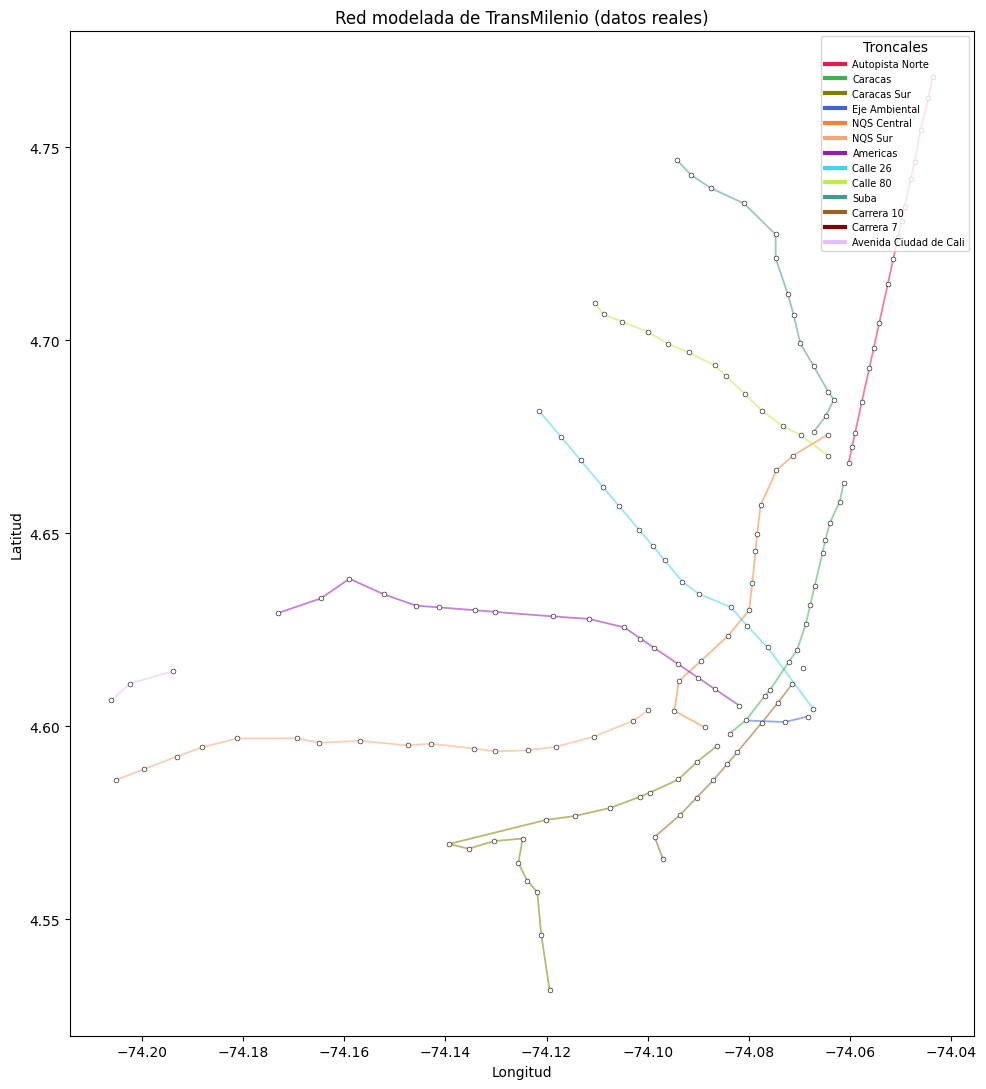

In [8]:
COLORES_LINEA = {
    "Autopista Norte": "#e6194B",
    "Caracas": "#3cb44b",
    "Caracas Sur": "#808000",
    "Eje Ambiental": "#4363d8",
    "NQS Central": "#f58231",
    "NQS Sur": "#f5a877",
    "Americas": "#911eb4",
    "Calle 26": "#42d4f4",
    "Calle 80": "#bfef45",
    "Suba": "#469990",
    "Carrera 10": "#9A6324",
    "Carrera 7": "#800000",
    "Avenida Ciudad de Cali": "#e6beff",
}


def construir_grafo_visual():
    G = nx.Graph()
    for nombre, (lat, lon) in ESTACIONES.items():
        G.add_node(nombre, pos=(lon, lat))
    for (a, b, linea, t) in CONECTA:
        G.add_edge(a, b, linea=linea, tiempo=t)
    return G


def dibujar_red(camino=None, titulo="Red modelada de TransMilenio (datos reales)"):
    G = construir_grafo_visual()
    pos = nx.get_node_attributes(G, "pos")

    fig, ax = plt.subplots(figsize=(10, 11))

    for (a, b, datos) in G.edges(data=True):
        color = COLORES_LINEA.get(datos["linea"], "gray")
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]],
                color=color, linewidth=1.3, alpha=0.55, zorder=1)

    xs = [p[0] for p in pos.values()]
    ys = [p[1] for p in pos.values()]
    ax.scatter(xs, ys, s=12, color="white", edgecolor="black", linewidth=0.4, zorder=2)

    if camino:
        estaciones_ruta = [estado[0] for estado, _ in camino]
        for a, b in zip(estaciones_ruta, estaciones_ruta[1:]):
            if a == b or a not in pos or b not in pos:
                continue
            ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]],
                    color="black", linewidth=3.2, alpha=0.9, zorder=3)
        for nombre in estaciones_ruta:
            x, y = pos[nombre]
            ax.annotate(nombre, (x, y), fontsize=7, xytext=(4, 4),
                        textcoords="offset points", zorder=5)
        ax.scatter([pos[estaciones_ruta[0]][0]], [pos[estaciones_ruta[0]][1]],
                    s=160, color="limegreen", edgecolor="black", zorder=4, label="Origen")
        ax.scatter([pos[estaciones_ruta[-1]][0]], [pos[estaciones_ruta[-1]][1]],
                    s=160, color="red", edgecolor="black", zorder=4, label="Destino")

    leyenda = [plt.Line2D([0], [0], color=c, lw=3, label=l) for l, c in COLORES_LINEA.items()]
    ax.legend(handles=leyenda, loc="upper right", fontsize=7, title="Troncales")

    ax.set_title(titulo)
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    plt.tight_layout()
    plt.show()


dibujar_red()


### 4.2. Mapa real de Bogotá (folium)

In [9]:
def _color_estacion(nombre):
    lineas_est = lineas_de(nombre)
    if len(lineas_est) > 1:
        return "black"
    return COLORES_LINEA.get(lineas_est[0], "gray") if lineas_est else "gray"


def mapa_bogota(camino=None, titulo=None):
    """Construye un mapa real de Bogota (folium) con la red completa y,
    opcionalmente, una ruta calculada resaltada."""
    lat_prom = sum(lat for lat, lon in ESTACIONES.values()) / len(ESTACIONES)
    lon_prom = sum(lon for lat, lon in ESTACIONES.values()) / len(ESTACIONES)

    m = folium.Map(location=[lat_prom, lon_prom], zoom_start=11, tiles="OpenStreetMap")

    estaciones_por_linea = defaultdict(list)
    for estacion, linea in PERTENECE:
        estaciones_por_linea[linea].append(estacion)

    for linea, lista_estaciones in estaciones_por_linea.items():
        orden = ORDEN_POR_LINEA.get(linea, lista_estaciones)
        puntos = [ESTACIONES[e] for e in orden]
        folium.PolyLine(
            puntos, color=COLORES_LINEA.get(linea, "gray"), weight=3, opacity=0.6,
            tooltip=f"Troncal {linea}",
        ).add_to(m)

    for nombre, (lat, lon) in ESTACIONES.items():
        lineas_txt = ", ".join(lineas_de(nombre))
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color="black",
            weight=1,
            fill=True,
            fill_color=_color_estacion(nombre),
            fill_opacity=0.9,
            popup=folium.Popup(f"<b>{nombre}</b><br>Lineas: {lineas_txt}", max_width=250),
            tooltip=nombre,
        ).add_to(m)

    if camino:
        estaciones_ruta = [estado[0] for estado, _ in camino]
        puntos_ruta = [ESTACIONES[e] for e in estaciones_ruta]
        folium.PolyLine(
            puntos_ruta, color="red", weight=6, opacity=0.9, tooltip="Ruta calculada",
        ).add_to(m)

        origen_est, destino_est = estaciones_ruta[0], estaciones_ruta[-1]
        folium.Marker(ESTACIONES[origen_est], tooltip=f"Origen: {origen_est}",
                      icon=folium.Icon(color="green")).add_to(m)
        folium.Marker(ESTACIONES[destino_est], tooltip=f"Destino: {destino_est}",
                      icon=folium.Icon(color="red")).add_to(m)

    if titulo:
        m.get_root().html.add_child(folium.Element(
            f'<h4 style="text-align:center">{titulo}</h4>'
        ))

    return m


mapa_bogota()


## 5. Ejemplos de uso

In [10]:
camino1, costo1 = planificar_ruta("Portal Norte - Unicervantes", "Portal Sur - JFK Coop. Financiera")


Ruta: Portal Norte - Unicervantes  ->  Portal Sur - JFK Coop. Financiera
Tiempo total estimado: 114.3 min   |   Transbordos: 3

  * Salir de Portal Norte - Unicervantes tomando la linea Autopista Norte
  -> Viajar por Autopista Norte: Portal Norte - Unicervantes -> Toberin - Foundever
  -> Viajar por Autopista Norte: Toberin - Foundever -> Calle 161
  -> Viajar por Autopista Norte: Calle 161 -> Mazuren
  -> Viajar por Autopista Norte: Mazuren -> Calle 146
  -> Viajar por Autopista Norte: Calle 146 -> Calle 142
  -> Viajar por Autopista Norte: Calle 142 -> Alcala - Colegio S. Tomas Dominicos
  -> Viajar por Autopista Norte: Alcala - Colegio S. Tomas Dominicos -> Prado
  -> Viajar por Autopista Norte: Prado -> Calle 127
  -> Viajar por Autopista Norte: Calle 127 -> Pepe Sierra Universidad UTEL
  -> Viajar por Autopista Norte: Pepe Sierra Universidad UTEL -> Calle 106 - Maletas Explora
  -> Viajar por Autopista Norte: Calle 106 - Maletas Explora -> Calle 100 - Marketmedios
  -> Viajar por

In [11]:
mapa_bogota(camino1, titulo="Ruta: Portal Norte -> Portal Sur")


In [12]:
camino2, costo2 = planificar_ruta("Portal 80", "Portal Americas")
mapa_bogota(camino2, titulo="Ruta: Portal 80 -> Portal Americas")


Ruta: Portal 80  ->  Portal Americas
Tiempo total estimado: 94.3 min   |   Transbordos: 2

  * Salir de Portal 80 tomando la linea Calle 80
  -> Viajar por Calle 80: Portal 80 -> Quirigua
  -> Viajar por Calle 80: Quirigua -> Carrera 90
  -> Viajar por Calle 80: Carrera 90 -> AV. Cali
  -> Viajar por Calle 80: AV. Cali -> Granja - Kr 77
  -> Viajar por Calle 80: Granja - Kr 77 -> Minuto de Dios
  -> Viajar por Calle 80: Minuto de Dios -> AV. Boyaca
  -> Viajar por Calle 80: AV. Boyaca -> Ferias
  -> Viajar por Calle 80: Ferias -> AV. 68
  -> Viajar por Calle 80: AV. 68 -> Carrera 53
  -> Viajar por Calle 80: Carrera 53 -> Carrera 47
  -> Viajar por Calle 80: Carrera 47 -> Escuela Militar
  -> Caminar de Escuela Militar a La Castellana (594 m) y tomar NQS Central
  -> Viajar por NQS Central: La Castellana -> Calle 75 - Zona M
  -> Viajar por NQS Central: Calle 75 - Zona M -> AV. Chile
  -> Viajar por NQS Central: AV. Chile -> 7 de Agosto
  -> Viajar por NQS Central: 7 de Agosto -> Movis

In [13]:
camino3, costo3 = planificar_ruta("Toberin - Foundever", "Museo del Oro")
mapa_bogota(camino3, titulo="Ruta: Toberin -> Museo del Oro")


Ruta: Toberin - Foundever  ->  Museo del Oro
Tiempo total estimado: 69.8 min   |   Transbordos: 2

  * Salir de Toberin - Foundever tomando la linea Autopista Norte
  -> Viajar por Autopista Norte: Toberin - Foundever -> Calle 161
  -> Viajar por Autopista Norte: Calle 161 -> Mazuren
  -> Viajar por Autopista Norte: Mazuren -> Calle 146
  -> Viajar por Autopista Norte: Calle 146 -> Calle 142
  -> Viajar por Autopista Norte: Calle 142 -> Alcala - Colegio S. Tomas Dominicos
  -> Viajar por Autopista Norte: Alcala - Colegio S. Tomas Dominicos -> Prado
  -> Viajar por Autopista Norte: Prado -> Calle 127
  -> Viajar por Autopista Norte: Calle 127 -> Pepe Sierra Universidad UTEL
  -> Viajar por Autopista Norte: Pepe Sierra Universidad UTEL -> Calle 106 - Maletas Explora
  -> Viajar por Autopista Norte: Calle 106 - Maletas Explora -> Calle 100 - Marketmedios
  -> Viajar por Autopista Norte: Calle 100 - Marketmedios -> Virrey
  -> Viajar por Autopista Norte: Virrey -> Calle 85
  -> Viajar por 

## 6. Interfaz interactiva: escribe tu origen (A) y tu destino (B)

Escribe el nombre de una estación en cada caja de texto (con autocompletado)
y pulsa **"Calcular ruta"**. El sistema resuelve el nombre escrito contra la
base de conocimiento (tolera mayúsculas/minúsculas y pequeños errores de
tipeo), ejecuta el motor de reglas + A\*, y muestra el resultado en texto y
en el mapa real de Bogotá.


In [14]:
print(f"Estaciones disponibles ({len(ESTACIONES)}):\n")
for nombre in sorted(ESTACIONES):
    print(f"  - {nombre}  (lineas: {', '.join(lineas_de(nombre))})")


Estaciones disponibles (152):

  - 21 Angeles  (lineas: Suba)
  - 7 de Agosto  (lineas: NQS Central)
  - AV. 1 Mayo  (lineas: Carrera 10)
  - AV. 68  (lineas: Calle 80)
  - AV. Americas - AV. Boyaca  (lineas: Americas)
  - AV. Boyaca  (lineas: Calle 80)
  - AV. Cali  (lineas: Calle 80)
  - AV. Chile  (lineas: NQS Central)
  - AV. ElDorado  (lineas: NQS Central)
  - Alcala - Colegio S. Tomas Dominicos  (lineas: Autopista Norte)
  - Alqueria  (lineas: NQS Sur)
  - Avenida Rojas - UNISALESIANA  (lineas: Calle 26)
  - Banderas  (lineas: Americas)
  - Biblioteca  (lineas: Caracas Sur)
  - Biblioteca Tintal  (lineas: Americas)
  - Bicentenario  (lineas: Carrera 10)
  - Bosa  (lineas: NQS Sur)
  - CAD  (lineas: NQS Central)
  - CAN  (lineas: Calle 26)
  - CC Paseo Villa del Rio - Madelena  (lineas: NQS Sur)
  - CDS - Carrera 32  (lineas: Americas)
  - Calle 100 - Marketmedios  (lineas: Autopista Norte)
  - Calle 106 - Maletas Explora  (lineas: Autopista Norte)
  - Calle 127  (lineas: Autopist

In [15]:
def resolver_estacion(texto):
    """Encuentra el nombre real de una estacion a partir de lo que escribio
    el usuario: coincidencia exacta (sin importar mayusculas), coincidencia
    parcial (substring) o, si no, la(s) mas parecida(s) por similitud de texto."""
    texto = (texto or "").strip()
    if not texto:
        return None, []

    nombres = list(ESTACIONES.keys())
    for nombre in nombres:
        if nombre.lower() == texto.lower():
            return nombre, []

    parciales = [n for n in nombres if texto.lower() in n.lower()]
    if len(parciales) == 1:
        return parciales[0], []
    if len(parciales) > 1:
        return None, parciales[:5]

    candidatos = difflib.get_close_matches(texto, nombres, n=3, cutoff=0.5)
    if len(candidatos) == 1:
        return candidatos[0], []
    return None, candidatos


nombres_estaciones = sorted(ESTACIONES.keys())

caja_origen = widgets.Combobox(
    placeholder="Escribe la estacion de origen (A)...",
    options=nombres_estaciones,
    description="Origen (A):",
    ensure_option=False,
    style={"description_width": "100px"},
    layout=widgets.Layout(width="480px"),
)

caja_destino = widgets.Combobox(
    placeholder="Escribe la estacion de destino (B)...",
    options=nombres_estaciones,
    description="Destino (B):",
    ensure_option=False,
    style={"description_width": "100px"},
    layout=widgets.Layout(width="480px"),
)

boton_calcular = widgets.Button(
    description="Calcular ruta",
    button_style="success",
    icon="search",
)

salida = widgets.Output()


def al_hacer_click(_boton):
    with salida:
        clear_output()
        origen, candidatos_o = resolver_estacion(caja_origen.value)
        destino, candidatos_d = resolver_estacion(caja_destino.value)

        hay_error = False
        if origen is None:
            hay_error = True
            if candidatos_o:
                print(f"No encontre exactamente '{caja_origen.value}'. Quisiste decir: {', '.join(candidatos_o)}?")
            else:
                print(f"No encontre ninguna estacion parecida a '{caja_origen.value}'.")
        if destino is None:
            hay_error = True
            if candidatos_d:
                print(f"No encontre exactamente '{caja_destino.value}'. Quisiste decir: {', '.join(candidatos_d)}?")
            else:
                print(f"No encontre ninguna estacion parecida a '{caja_destino.value}'.")
        if hay_error:
            return

        if origen == destino:
            print("El origen y el destino son la misma estacion.")
            return

        camino, costo = planificar_ruta(origen, destino)
        if camino is not None:
            display(mapa_bogota(camino, titulo=f"Ruta: {origen} -> {destino}"))


boton_calcular.on_click(al_hacer_click)

display(widgets.VBox([
    widgets.HBox([caja_origen, caja_destino, boton_calcular]),
    salida,
]))


## 7. Análisis: efecto de la heurística

Comparamos el número de **estados expandidos** por A\* usando la heurística
de distancia geográfica frente a una búsqueda **no informada** equivalente
(heurística $h=0$, equivalente a Dijkstra) sobre esta red real, mucho más
grande que un ejemplo de juguete.


In [16]:
def a_star_sin_heuristica(origen, destino, transiciones=TRANSICIONES):
    """Version de A* con h=0 en todos los estados (equivalente a Dijkstra)."""
    contador = 0
    frontera = []
    for e0 in [(origen, l) for l in lineas_de(origen)]:
        heapq.heappush(frontera, (0.0, 0.0, contador, e0, [(e0, None)]))
        contador += 1

    visitados = {}
    expandidos = 0

    while frontera:
        f, g, _, estado, camino = heapq.heappop(frontera)
        if estado in visitados and visitados[estado] <= g:
            continue
        visitados[estado] = g
        expandidos += 1

        if estado[0] == destino:
            return camino, g, expandidos

        for (estado_sig, costo, explicacion) in transiciones.get(estado, []):
            g2 = g + costo
            if estado_sig in visitados and visitados[estado_sig] <= g2:
                continue
            heapq.heappush(frontera, (g2, g2, contador, estado_sig, camino + [(estado_sig, explicacion)]))
            contador += 1

    return None, math.inf, expandidos


for origen, destino in [
    ("Portal Norte - Unicervantes", "Portal Sur - JFK Coop. Financiera"),
    ("Portal 80", "Portal Americas"),
]:
    _, costo_a, exp_a = a_star(origen, destino, contar_expandidos=True)
    _, costo_d, exp_d = a_star_sin_heuristica(origen, destino)
    print(f"{origen} -> {destino}")
    print(f"   A* con heuristica geografica : costo={costo_a:.1f} min, estados expandidos={exp_a}")
    print(f"   Busqueda no informada (h=0)   : costo={costo_d:.1f} min, estados expandidos={exp_d}")
    print()


Portal Norte - Unicervantes -> Portal Sur - JFK Coop. Financiera
   A* con heuristica geografica : costo=114.3 min, estados expandidos=124
   Busqueda no informada (h=0)   : costo=114.3 min, estados expandidos=144

Portal 80 -> Portal Americas
   A* con heuristica geografica : costo=94.3 min, estados expandidos=88
   Busqueda no informada (h=0)   : costo=94.3 min, estados expandidos=136



Ambas búsquedas encuentran el **mismo costo óptimo**, pero A\* con la
heurística geográfica expande **menos estados** — la diferencia se nota
todavía más en esta red real de más de 150 estaciones que en un ejemplo
pequeño, porque una búsqueda no informada explora uniformemente en todas
direcciones mientras A\* dirige la exploración hacia el destino.


## 8. Conclusiones

* La **representación del conocimiento** en forma de hechos lógicos
  (`estacion`, `pertenece`, `conecta`), poblada con **datos reales y
  oficiales** de TransMilenio (152 estaciones, 13 troncales), permite
  describir la red de manera declarativa y reproducible a partir de una
  fuente pública y verificable.
* El **sistema basado en reglas** (R1-R4) infiere automáticamente, mediante
  encadenamiento hacia adelante, todas las transiciones posibles del
  sistema —incluyendo transbordos tanto en la misma estación como entre
  plataformas distintas de un mismo complejo real, detectados por
  proximidad geográfica— sin codificar el grafo de transporte a mano.
* La **búsqueda heurística A\***, con una heurística geográfica admisible,
  encuentra la ruta de menor tiempo estimado entre dos estaciones reales
  cualesquiera, de forma más eficiente que una búsqueda no informada.
* La **interfaz interactiva** (cajas de texto + mapa real con `folium`)
  hace que el sistema sea utilizable por cualquier persona: escribe el
  origen y el destino reales y obtiene la ruta sobre el mapa de Bogotá.

**Limitaciones honestas de este ejercicio** (para que quede claro qué tan
"real" es cada parte):

* El **orden de las estaciones** dentro de cada troncal se reconstruyó con
  un heurístico de vecino más cercano (no viene dado por el dataset oficial
  usado, que no incluye el orden de paradas tipo GTFS); se validó contra el
  orden real conocido de varias troncales y coincide, pero no está
  garantizado al 100% en tramos con ramales o bucles complejos.
* Los **tiempos de viaje** son estimados (distancia real / velocidad
  comercial promedio), no provienen de datos de operación en tiempo real.
* Los **transbordos por proximidad (R4)** se infieren geométricamente con un
  umbral de distancia; no reflejan si existe físicamente un puente peatonal
  o una conexión directa entre dos plataformas.
* Varias estaciones aparecen como **"Temporal"** en el nombre porque así
  las reporta el dataset oficial (relocalizaciones temporales por obras,
  p. ej. de la Primera Línea del Metro) — es decir, reflejan el estado
  *actual* real del sistema, no un error de este ejercicio.
* La troncal **Avenida Ciudad de Cali** queda geográficamente aislada del
  resto de la red en este modelo (sus estaciones más cercanas a otra
  troncal están a más de 2 km): en la operación real esa troncal se conecta
  al resto del sistema mediante **rutas alimentadoras (buses zonales)**, que
  no están incluidas en este ejercicio (solo se modelan estaciones
  *troncales*). El sistema lo señala honestamente devolviendo "no se
  encontró ruta" en vez de inventar una conexión inexistente.

**Posibles extensiones:**

* Sustituir la reconstrucción de orden por un feed GTFS oficial (cuando se
  consiga acceso estable) para tener la secuencia exacta de paradas y
  tiempos reales de viaje.
* Incorporar las rutas alimentadoras (buses zonales) además de las
  troncales.
* Optimizar por número de transbordos, por costo del pasaje, o combinar
  varios criterios en la función de costo `g`.
